# Анализ логов работы учащихся в цифровой среде — исправленная версия

Ноутбук воспроизводит анализ данных задания «Спектакль» с устранением
методологических и программных ошибок первых трёх версий
(`hse_project.ipynb`, `hse_project-ver2.ipynb`, `hse_project-ver3.ipynb`).

Полный разбор того, что именно было исправлено и почему, — в [REPORT.md](REPORT.md).

Вся логика вынесена в модули `src/`, чтобы её можно было тестировать
(`pytest`) и переиспользовать; ноутбук показывает результаты и их
интерпретацию.

## Задача

Респондент проходит симуляцию соцсети: создаёт сообщество, настраивает
приватность, отвечает на письма учителя, личные сообщения и комментарии.
Каждое действие пишется в лог.

**Вопрос:** можно ли по логу предсказать уровень цифровой грамотности
(`GGlevel`, 4 уровня) и какие действия его выдают?

`GGlevel` — порядковая переменная, поэтому решается задача **классификации
с учётом порядка**, а не регрессии.

In [1]:
import sys
import warnings

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

sys.path.insert(0, ".")
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.width", 200)

from src.data_prep import load_dataset, nominal_columns, numeric_columns
from src.modeling import (
    build_models, evaluate, permutation_ranking, split,
    standardised_coefficients, test_report,
)
from src.factor import (
    adequacy, dominant_items, factor_block, fit_factors, mca, parallel_analysis,
)

## 1. Загрузка и подготовка данных

Три вещи, сделанные иначе, чем в исходной версии:

1. **Пропуск закодирован тремя способами** — пустая ячейка, `'undefined'`
   и опечатка `'nun'`. Все три сводятся к `NaN`. В исходной версии
   `'undefined'` оставался полноценной категорией.
2. **Ни одна строка не удаляется.** Исходная версия теряла 20 % выборки
   через `dropna`, причём выбывали в первую очередь те, кто не дошёл до
   конца задания, — то есть выборка смещалась в сторону сильных.
3. **`GGfscore` исключён из признаков.** Это непрерывный балл, из которого
   нарезан `GGlevel`, то есть прямая утечка целевой переменной.

In [2]:
features, target, score = load_dataset("Спектакль_utf8_2.xlsx")

print(f"наблюдений: {len(features)}")
print(f"признаков:  {features.shape[1]} "
      f"({len(numeric_columns(features))} числовых, "
      f"{len(nominal_columns(features))} номинальных)")
target.value_counts().sort_index()

наблюдений: 2796
признаков:  56 (27 числовых, 29 номинальных)


GGlevel
0    493
1    845
2    931
3    527
Name: count, dtype: int64

### Как разобраны испорченные Excel'ем столбцы

Столбцы `savepicture`, `picturechoose`, `picturechoosedelete`, `citationcode`
хранят **последовательности** кликов («2,4,5»). Excel в русской локали
исказил их тремя разными способами:

| в файле | что это на самом деле | как прочитал Excel |
|---|---|---|
| `'2,4,5'` | последовательность 2 → 4 → 5 | уцелело |
| `2.4` | последовательность 2 → 4 | дробь (запятая = десятичный разделитель) |
| `'5.0999999999999996'` | последовательность 5 → 1 | дробь + шум float |
| `Timestamp('2024-01-02')` | последовательность 2 → 1 | дата «2 января» |

Гипотеза проверяема: у всех значений-дат день и месяц лежат строго в
диапазоне 1–8 — ровно в алфавите кодов картинок.

Исходная версия подавала эти значения в `OrdinalEncoder` как строки,
из-за чего последовательность «2,4,5» превращалась в произвольное число
и участвовала в линейной регрессии как величина.

In [3]:
from src.data_prep import parse_sequence

for raw in ["1,5,3,2,4", 2.4, "5.0999999999999996", pd.Timestamp("2024-01-02"), 4]:
    print(f"{str(raw):25s} -> {parse_sequence(raw)}")

1,5,3,2,4                 -> [1, 5, 3, 2, 4]
2.4                       -> [2, 4]
5.0999999999999996        -> [5, 1]
2024-01-02 00:00:00       -> [2, 1]
4                         -> [4]


Из последовательностей строятся осмысленные признаки: длина (сколько
действий), число повторов. Сам код объекта («какую картинку выбрал первой»)
уходит в номинальный блок — это метка, а не величина.

Отдельно выделены признаки по скопированному тексту: задание проверяет,
сумеет ли респондент вычленить рабочую почту, поэтому важно, найден ли
верный адрес и сколько лишнего прихвачено.

## 2. Моделирование

Разбиение стратифицированное, с фиксированным `random_state`: без него
результаты не воспроизводятся, и в исходной работе baseline менялся от
запуска к запуску (0.316 против 0.327 на одних и тех же данных).

Отбор модели идёт по кросс-валидации внутри обучающей части; отложенная
выборка трогается один раз в самом конце.

In [4]:
x_train, x_test, y_train, y_test = split(features, target)
models = build_models(features)

cv_table = evaluate(models, x_train, y_train)
cv_table.round(4)

,model,accuracy,accuracy_std,f1_macro,f1_macro_std
2,logreg,0.5434,0.0168,0.5548,0.0123
3,random_forest,0.5568,0.0299,0.5511,0.0363
4,gradient_boosting,0.5416,0.0351,0.5474,0.0410
1,baseline_stratified,0.2768,0.0201,0.2565,0.0191
0,baseline_most_frequent,0.3332,0.0003,0.1250,0.0001


### Проверка на адекватность

Здесь исправлена ключевая ошибка исходной работы. Там сравнивалось:

```python
ac_dmc  = dmc.score(x_test, y_test)    # accuracy классификатора
accuracy = model.score(x_test, y_test) # R² линейной регрессии
```

`LinearRegression.score` возвращает **R²**, `DummyClassifier.score` —
**долю верных ответов**. Вывод «0.65 против 0.25» сравнивал разные шкалы.

Ниже все модели — и базовые, и обученные — меряются **одним набором
метрик**:

* `accuracy` — доля верных уровней;
* `f1_macro` — учитывает несбалансированность классов;
* `quadratic_kappa` — учитывает **порядок** уровней: спутать 0 с 3 хуже,
  чем 1 с 2;
* `mae_levels` — на сколько уровней модель ошибается в среднем.

In [5]:
reports = {}
for name, model in models.items():
    model.fit(x_train, y_train)
    reports[name] = test_report(model, x_test, y_test)

pd.DataFrame(reports).T.round(4)

,accuracy,f1_macro,quadratic_kappa,mae_levels
baseline_most_frequent,0.3321,0.1247,0.0000,0.8446
baseline_stratified,0.2536,0.2386,-0.0021,1.1196
logreg,0.5518,0.5619,0.6721,0.5000
random_forest,0.5321,0.5398,0.6427,0.5125
gradient_boosting,0.5232,0.5333,0.6558,0.5268


**Результат.** Логистическая регрессия даёт accuracy ≈ 0.55 против 0.33
у базовой модели «всегда самый частый класс» — по одной и той же метрике.
Взвешенная каппа 0.67 означает существенное согласие с истинными уровнями.
Средняя ошибка — половина уровня.

Модель работает, но заметно скромнее, чем можно было подумать по исходным
0.65: там это был R² на испорченных данных.

Логистическая регрессия не уступает случайному лесу и бустингу — связь
признаков с уровнем в основном аддитивная, сложных взаимодействий между
действиями данные не показывают.

## 3. Какие действия выдают уровень грамотности

Коэффициенты линейной модели в исходной работе интерпретировать было
нельзя: признаки не масштабировались (время в минутах против кодов 0–3),
а категории кодировались порядковыми номерами по алфавиту.

Здесь используется **permutation importance** — насколько падает качество,
если разрушить связь признака с целевой переменной. Эта оценка не зависит
от вида модели и от способа кодирования категорий.

In [6]:
importance = permutation_ranking(models["logreg"], x_test, y_test)
importance.head(20).round(4)

,признак,падение_f1,std
0,copymail_is_empty,0.0490,0.0130
1,private6,0.0307,0.0129
2,fulltime_is_missing,0.0306,0.0039
3,openglasha_is_missing,0.0306,0.0039
4,notion_is_missing,0.0306,0.0039
5,loginchoose,0.0284,0.0093
6,copymail_has_correct_email,0.0284,0.0111
7,wall2comment4,0.0275,0.0125
8,private3,0.0262,0.0084
9,notion,0.0186,0.0122


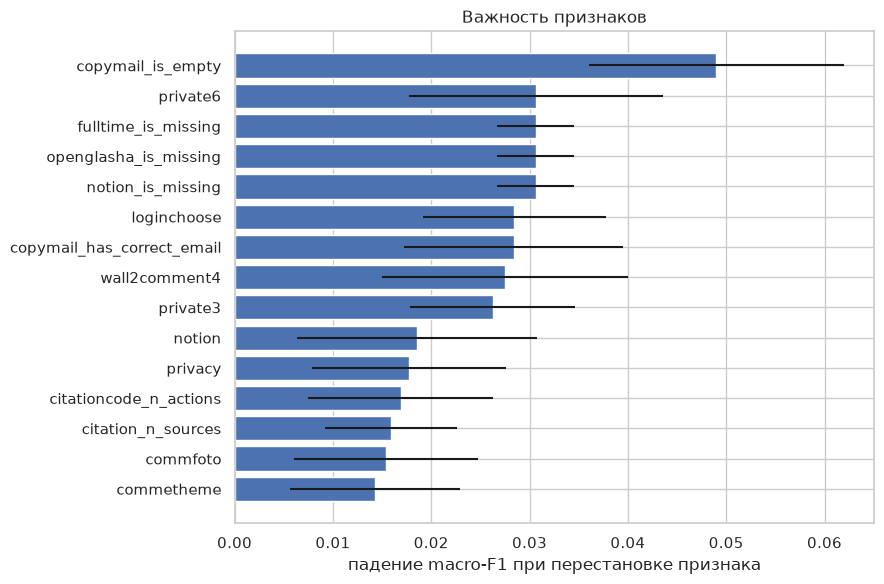

In [7]:
top = importance.head(15).iloc[::-1]
plt.figure(figsize=(9, 6))
plt.barh(top["признак"], top["падение_f1"], xerr=top["std"], color="#4C72B0")
plt.xlabel("падение macro-F1 при перестановке признака")
plt.title("Важность признаков")
plt.tight_layout()
plt.show()

## 4. Факторный анализ числового блока

Факторный анализ строится на корреляциях Пирсона и требует переменных,
для которых расстояние осмысленно. У номинальных категорий («почта» /
«поиск») его нет, поэтому классический факторный анализ применяется
**только к числовому блоку** — времени, счётчикам, характеристикам
последовательностей.

Сначала — проверка пригодности. В отличие от исходной версии, здесь
дополнительно считается определитель корреляционной матрицы: если он
нулевой, матрица вырождена и χ² Бартлетта считать нельзя. В исходной
работе этот случай наступил (`divide by zero encountered in det`), но
результат всё равно был истолкован как значимый.

In [8]:
behaviour = [c for c in numeric_columns(features) if not c.endswith("_is_missing")]
block = factor_block(features, behaviour)

for key, value in adequacy(block).items():
    print(f"{key}: {value}")

n_rows: 2796
determinant: 2.704901171594466e-07
bartlett_chi2: 42170.569921228445
bartlett_p: 0.0
kmo: 0.5106613291360065
matrix_is_singular: False


**KMO = 0.51.** Это ниже общепринятого порога приемлемости (0.6).
Общей факторной структуры в поведенческом блоке практически нет — и это
содержательный результат, а не техническая заминка.

Для сравнения: исходная работа получила KMO = 0.96, но на данных, где
последовательности были закодированы произвольными числами, а сама
целевая переменная участвовала в анализе.

### Сколько факторов выделять

Критерий Кайзера («собственное значение больше 1») систематически завышает
число факторов. Корректный способ — **параллельный анализ Хорна**:
сравнить наблюдаемые собственные значения с теми, что возникают на
случайных данных того же размера.

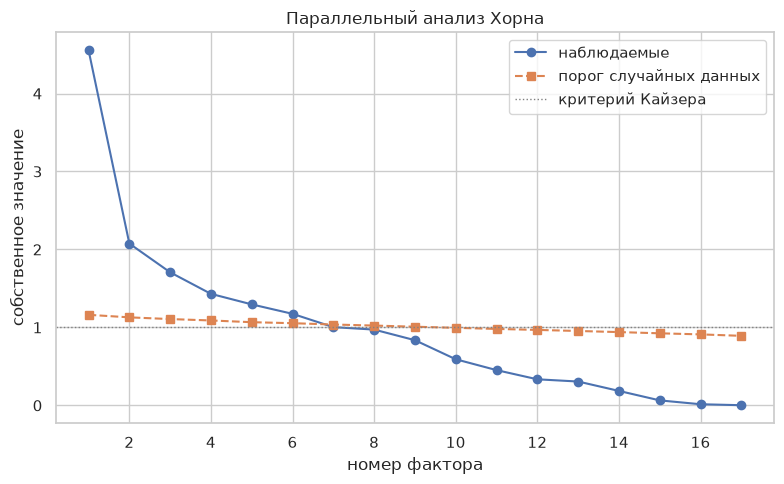

оставляем факторов: 6
критерий Кайзера дал бы: 7


In [9]:
horn = parallel_analysis(block, n_iter=200)

plt.figure(figsize=(8, 5))
plt.plot(horn["фактор"], horn["собственное_значение"], "o-", label="наблюдаемые")
plt.plot(horn["фактор"], horn["порог_случайности"], "s--",
         label="порог случайных данных")
plt.axhline(1, color="gray", lw=1, ls=":", label="критерий Кайзера")
plt.xlabel("номер фактора"); plt.ylabel("собственное значение")
plt.title("Параллельный анализ Хорна"); plt.legend(); plt.tight_layout()
plt.show()

n_factors = int(horn["оставляем"].sum())
print(f"оставляем факторов: {n_factors}")
print(f"критерий Кайзера дал бы: {int((horn['собственное_значение'] > 1).sum())}")

In [10]:
loadings, variance = fit_factors(block, n_factors, rotation="promax")
print(variance.round(3).to_string())
print()
for factor, items in dominant_items(loadings, 0.4).items():
    print(f"{factor}: {'; '.join(items) if items else 'нет значимых нагрузок'}")

                  Фактор1  Фактор2  Фактор3  Фактор4  Фактор5  Фактор6
дисперсия           2.299    2.086    1.826    1.686    1.486    0.899
доля_дисперсии      0.135    0.123    0.107    0.099    0.087    0.053
накопленная_доля    0.135    0.258    0.365    0.465    0.552    0.605

Фактор1: copymail_len (+0.98); copymail_is_empty (-0.79); copymail_has_correct_email (+0.76)
Фактор2: picturechooseN (+1.00); picturechoose_n_actions (+0.86)
Фактор3: citationcode_n_actions (+0.97); citation_n_sources (+0.91)
Фактор4: savepictureN (+0.83); savepicture_n_actions (+0.76); savepicture_n_repeats (+0.54)
Фактор5: picturechoosedelete_n_actions (+0.99); picturechoosedelete_n_repeats (+0.65)
Фактор6: copymail_is_exact_email (+0.69); copymail_len (-0.52)


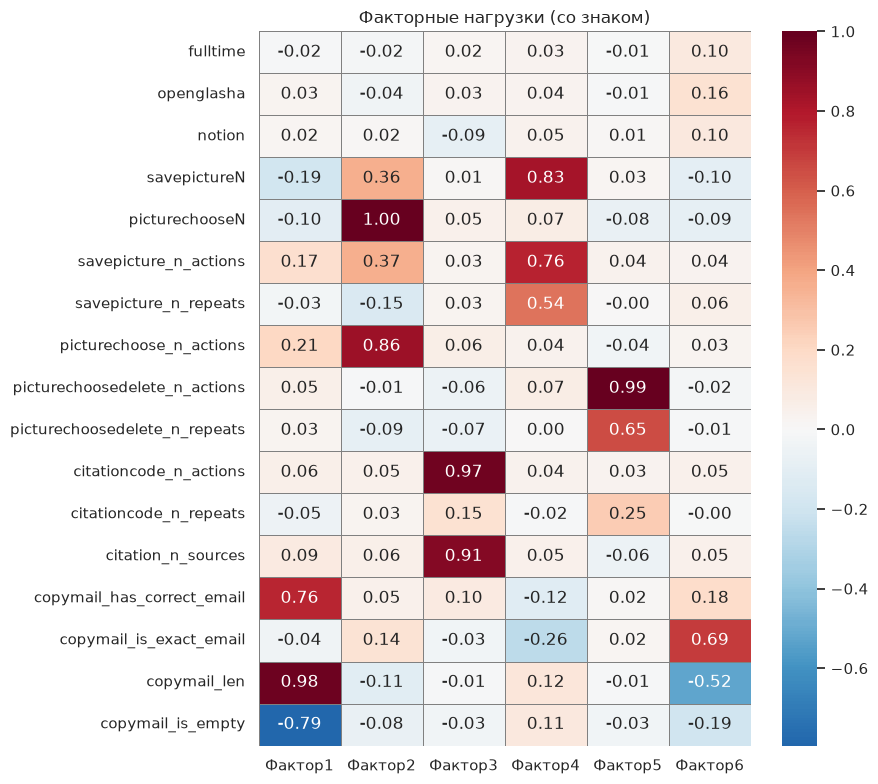

In [11]:
plt.figure(figsize=(9, 8))
sns.heatmap(loadings, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            linewidths=0.5, linecolor="gray")
plt.title("Факторные нагрузки (со знаком)")
plt.tight_layout()
plt.show()

Нагрузки показаны **со знаком**. В исходной версии стояло
`loadings = np.abs(loadings)`, после чего направление связи терялось,
а выводы о «повышающем влиянии» фактора уже не опирались на данные.

**Вывод отрицательный и важный:** каждый фактор просто собирает признаки,
порождённые *одним и тем же* исходным столбцом (фактор 2 — всё про
`picturechoose`, фактор 3 — всё про `citation`, и так далее). Это артефакт
конструирования признаков, а не латентная компетентность. Сквозного
общего фактора в поведенческом блоке нет.

## 5. Анализ соответствий (MCA) номинального блока

Содержательная часть задания — сами ответы: что респондент написал в
личку, какие настройки приватности выбрал. Эти переменные номинальные,
и для них корректный аналог факторного анализа — **множественный анализ
соответствий**. Он работает с таблицей индикаторов, не требует
упорядоченности вариантов и не приписывает категориям числовых значений.

In [12]:
summary, category_coords, respondent_coords = mca(
    features[nominal_columns(features)], n_components=6
)
summary.round(4)

,ось,собственное_значение,доля_инерции_бенцекри
0,1,0.8345,0.9749
1,2,0.1242,0.0123
2,3,0.0833,0.0036
3,4,0.0819,0.0034
4,5,0.0797,0.0031
5,6,0.0766,0.0027


Ключевая проверка: связаны ли найденные оси с внешним критерием?
Оси строились **без обращения к целевой переменной**, поэтому корреляция
с ней — честная валидация структуры.

In [13]:
links = []
for axis in respondent_coords.columns:
    links.append({
        "ось": axis,
        "rho_GGlevel": spearmanr(respondent_coords[axis], target).statistic,
        "rho_GGfscore": spearmanr(respondent_coords[axis], score).statistic,
    })
links = pd.DataFrame(links)
links.round(3)

,ось,rho_GGlevel,rho_GGfscore
0,Ось1,-0.316,-0.333
1,Ось2,-0.678,-0.703
2,Ось3,-0.055,-0.054
3,Ось4,-0.208,-0.211
4,Ось5,0.010,0.014
5,Ось6,0.063,0.059


**Две содержательные оси.**

* **Ось 1** забирает 97 % инерции, но с грамотностью связана слабо
  (ρ ≈ −0.32). Её полюс — сплошные категории `__MISSING__`: это ось
  «дошёл до конца задания против бросил». Доминирующая структура в данных —
  просто факт незавершения.
* **Ось 2** — настоящая ось компетентности: ρ ≈ **−0.70** с непрерывным
  баллом. Знак у осей SVD произвольный, поэтому разворачиваем ось так,
  чтобы «больше» означало «компетентнее».

In [14]:
main_axis = links.loc[links["rho_GGfscore"].abs().idxmax(), "ось"]
sign = -1 if links.set_index("ось").loc[main_axis, "rho_GGfscore"] < 0 else 1
oriented = category_coords[main_axis] * sign

print("полюс НИЗКОЙ компетентности:")
for name, value in oriented.sort_values().head(8).items():
    print(f"  {value:+.2f}  {name}")
print("\nполюс ВЫСОКОЙ компетентности:")
for name, value in oriented.sort_values().tail(8).items():
    print(f"  {value:+.2f}  {name}")

полюс НИЗКОЙ компетентности:
  -1.72  private2_О, прикольно, пусть все посмотрят этот сайт!
  -1.44  commtypes_Бизнес
  -1.40  picturechoose_first_6
  -1.37  citationcode_first_6
  -1.30  wall2comment5_5
  -1.26  savepicture_first_6
  -1.22  wall4_Давайте все напишут свои номера телефонов, а мы им позвоним
  -1.18  wall2comment4_1

полюс ВЫСОКОЙ компетентности:
  +0.61  private3_5
  +0.62  wall2comment4_4
  +0.63  picturechoosedelete_first_4
  +0.68  picturechoose_first_5
  +0.75  citationcode_first_2
  +0.81  savepicture_first_5
  +0.90  picturechoosedelete_first_5
  +1.03  citationcode_first_5


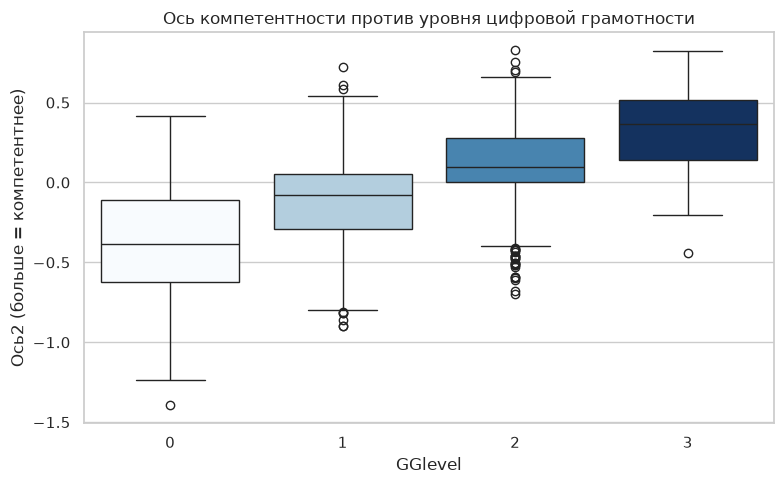

In [15]:
frame = pd.DataFrame({"ось": respondent_coords[main_axis] * sign, "GGlevel": target})
plt.figure(figsize=(8, 5))
sns.boxplot(data=frame, x="GGlevel", y="ось", hue="GGlevel",
            palette="Blues", legend=False)
plt.ylabel(f"{main_axis} (больше = компетентнее)")
plt.title("Ось компетентности против уровня цифровой грамотности")
plt.tight_layout()
plt.show()

Полюс низкой компетентности собран из **небезопасных** ответов:

* `private2` — «О, прикольно, пусть все посмотрят этот сайт!» (переслать
  подозрительную ссылку дальше);
* `wall4` — «Давайте все напишут свои номера телефонов, а мы им позвоним»
  (публикация персональных данных);
* `commtypes` — «Бизнес» вместо сообщества по интересам.

То есть найденная ось — это **ось безопасного поведения в сети**, и она
воспроизводится из логов без обращения к оценке.

## 6. Выводы

**1. Модель работает, но скромнее заявленного.**
Accuracy 0.55 против 0.33 у базовой модели, взвешенная каппа 0.67 —
по одной и той же метрике. Логистическая регрессия не уступает лесу и
бустингу, то есть связь в основном аддитивная. Исходные «0.65 против
0.25» сравнивали R² с долей верных ответов и считались на испорченных
данных.

**2. У 16 % респондентов лога фактически нет.**
Надо различать два вида пропуска. Сбой логирования (`fulltime`,
`openglasha`, `notion` не записаны) с уровнем **не связан** — χ², p = 0.42;
на таких респондентах модель ставит всем модальный класс и даёт accuracy
0.34, тогда как на остальных — 0.593. А вот недоведение задания до конца
(пустое поле адреса: 38.5 % против 15.6 %) — уже содержательный сигнал.
Первая ось MCA (97 % инерции) отражает именно техническую проблему.

**3. Паттерны работы, различающие уровни** (2403 чел. с исправным логом):
проверка источников 0.20 → 1.27 (ρ = +0.48), нахождение верного адреса
34 % → 95 % (ρ = +0.47), ошибки заполнения 1.14 → 0.22 (ρ = −0.36),
вызовы ассистента 2.73 → 1.72 (ρ = −0.11). Время различает слабо
(ρ = +0.07), но знак положительный: сильные тратят на задание **больше**
времени, спешка — признак слабости.

Отдельно: «скопировал ровно адрес, без контекста» связан с баллом
**отрицательно** (ρ = −0.13) — сильные копируют адрес вместе с
пояснением, чей он.

**4. Приватность — самый резкий одиночный маркер:** открытое сообщество
выбирают 61 % респондентов нулевого уровня против 12 % третьего.

**5. Небезопасные ответы специфичны, но нечувствительны.** «Пусть все
посмотрят этот сайт» — 10.4 % на нулевом уровне и 0 % на третьем. Выше
нулевого уровня почти не встречаются, но и внутри него их даёт
меньшинство. Годятся как триггер тревоги, не как шкала.

**6. Единого поведенческого фактора нет, содержательный конструкт один.**
KMO числового блока 0.51 (ниже порога), все факторы лишь группируют
признаки одного происхождения. Зато вторая ось MCA коррелирует с баллом
на ρ = −0.70, будучи построенной без обращения к нему, и её полюса —
безопасные против небезопасных решений. Инструмент измеряет **одно**:
осторожность поведения в сети. Разделение на три умения, заявленное в
первой версии работы, данными не подтверждается.

Подробный разбор — в [CONCLUSIONS.md](CONCLUSIONS.md).

## Воспроизведение

```bash
pip install -r requirements.txt
cd education_hse_project

python run_analysis.py   # полный прогон, таблицы в results/
python bug_impact.py     # оценка вклада главной ошибки исходной версии
pytest                   # тесты разбора данных
```